# 第069讲 主成分分析的推导

从二维手算出发，将方差最大化与重构最小化联系起来。所有输出在真实内核顺序执行。直接先修第007、012、021、029讲。

In [1]:
import numpy as np
from pathlib import Path
from IPython.display import display, Image
from common import load_data
from pca import fit, transform, reconstruct
from experiment import run, matrix
data=load_data()
print({name: len(v["id"]) for name,v in data.items()})

{'train': 320, 'test': 160, 'signal_train': 400, 'signal_test': 200}


## 四点手算
每列均值0；协方差分母n-1=3；投影两对重合点。

In [2]:
H=np.array([[2.,1],[1,2],[-1,-2],[-2,-1]])
m=fit(H,1)
print("covariance", H.T@H/3)
print("eigenvalues",m["eigenvalues"])
print("scores",transform(m,H).ravel())
print("reconstruction",reconstruct(m,H))
print("SSE",np.sum((H-reconstruct(m,H))**2))

covariance [[3.33333333 2.66666667]
 [2.66666667 3.33333333]]
eigenvalues [6.         0.66666667]
scores [ 2.12132034  2.12132034 -2.12132034 -2.12132034]
reconstruction [[ 1.5  1.5]
 [ 1.5  1.5]
 [-1.5 -1.5]
 [-1.5 -1.5]]
SSE 2.0


## 固定实验与库对照
比较投影矩阵和重构，而不是要求主轴符号相同。

In [3]:
report=run()
print(report["library_errors"])
for row in report["reconstruction_curve"]:
    print(row["k"],row["train_mean_squared_distance"],row["test_mean_squared_distance"],row["cumulative_variance_ratio"])

{'projector': 0.0, 'eigenvalues': 0.0, 'reconstruction': 3.552713678800501e-15, 'eigh_projector': 9.992007221626409e-16}
1 3.360424498068331 3.871973593273664 0.8957676321426093
2 0.08819235321086062 0.08829860479256371 0.9972644831605747
3 0.06158765912111099 0.06440317745485083 0.9980896974341553
4 0.038406257284063994 0.04228889684878499 0.9988087293317974
5 0.01799383705655126 0.01812993502071221 0.9994418740119522
6 8.944698429546253e-30 1.0705006541953302e-29 1.0


In [4]:
X=matrix(data["train"]); model=fit(X,2)
print("W W.T", model["components"]@model["components"].T)
print("residual orthogonality",np.max(abs((X-reconstruct(model,X))@model["components"].T)))
print("SSE identity",np.sum((X-reconstruct(model,X))**2),(len(X)-1)*model["eigenvalues"][2:].sum())

W W.T [[ 1.00000000e+00 -3.19798745e-17]
 [-3.19798745e-17  1.00000000e+00]]
residual orthogonality 9.499710834554229e-15
SSE identity 28.221553027475398 28.22155302747543


## 符号与平移不变性
翻转轴与分数的符号不改变重构。

In [5]:
import copy
flipped=copy.deepcopy(model); flipped["components"]*=-1
print("sign-flip reconstruction error",np.max(abs(reconstruct(model,X)-reconstruct(flipped,X))))
print("training mean",model["mean"])

sign-flip reconstruction error 0.0
training mean [10.11192613 -2.86843855  2.20552895 -0.08077064  5.0989752  -1.99100144]


## 任务目标的边界
解释方差很高不自动保证分类信息还在。

In [6]:
print({k:report["prediction_counterexample"][k] for k in ["variance_ratio_pc1","full_accuracy","pc1_accuracy"]})
print(report["centering"])

{'variance_ratio_pc1': 0.9984306512395064, 'full_accuracy': 0.99, 'pc1_accuracy': 0.48}
{'centered_rank2_sse': 28.221553027475398, 'uncentered_rank2_sse': 1020.797257509799, 'train_mean': [10.111926130186983, -2.868438553237028, 2.2055289508013707, -0.08077064312220002, 5.098975196176931, -1.9910014407179535], 'shifted_test_score_mean': [2.2122178461515096, -0.9737951833271958], 'incorrect_self_centered_mean': [-2.0483614804334137e-15, 9.48546796664118e-16]}


In [7]:
from plots import draw
names=draw(report,Path("outputs/notebook-figures"))
print("generated",len(names),"figures")

generated 7 figures


### 手算几何

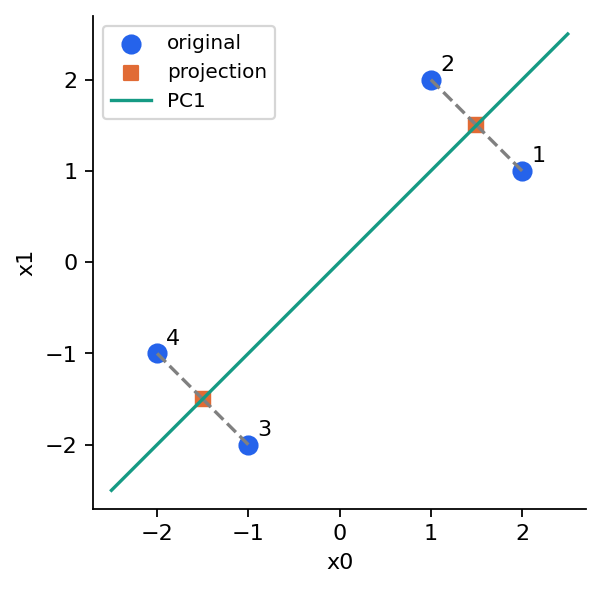

In [8]:
display(Image(filename="outputs/notebook-figures/01_hand_projection.png"))

### 方差目标

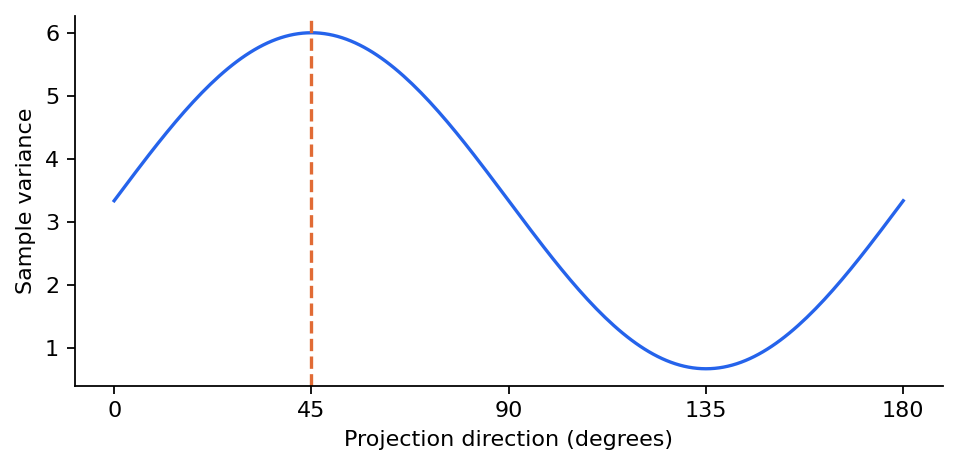

In [9]:
display(Image(filename="outputs/notebook-figures/02_variance_direction.png"))

### 协方差谱

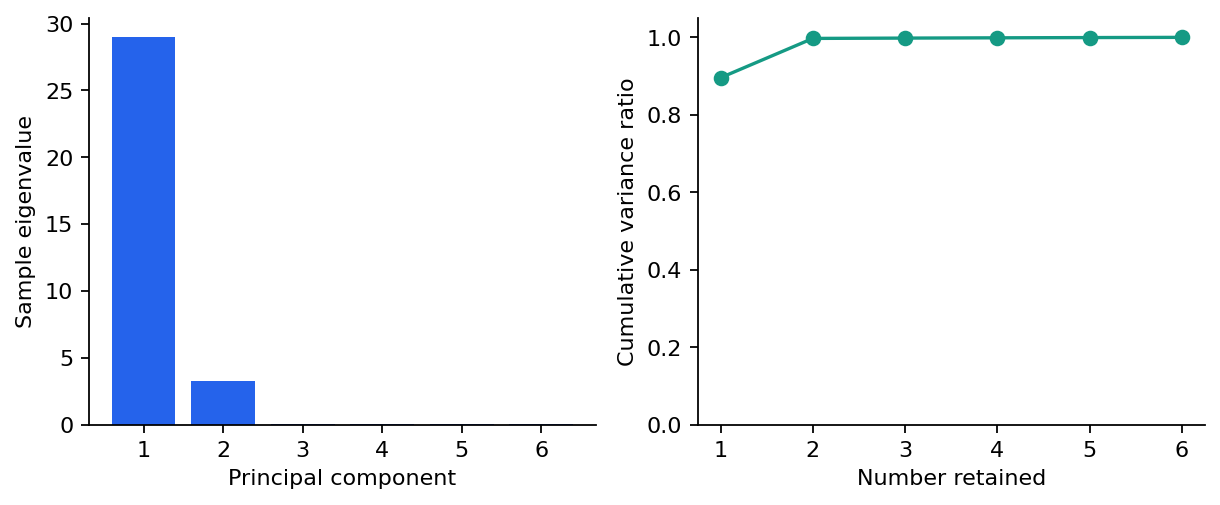

In [10]:
display(Image(filename="outputs/notebook-figures/03_spectrum.png"))

### 维数与重构

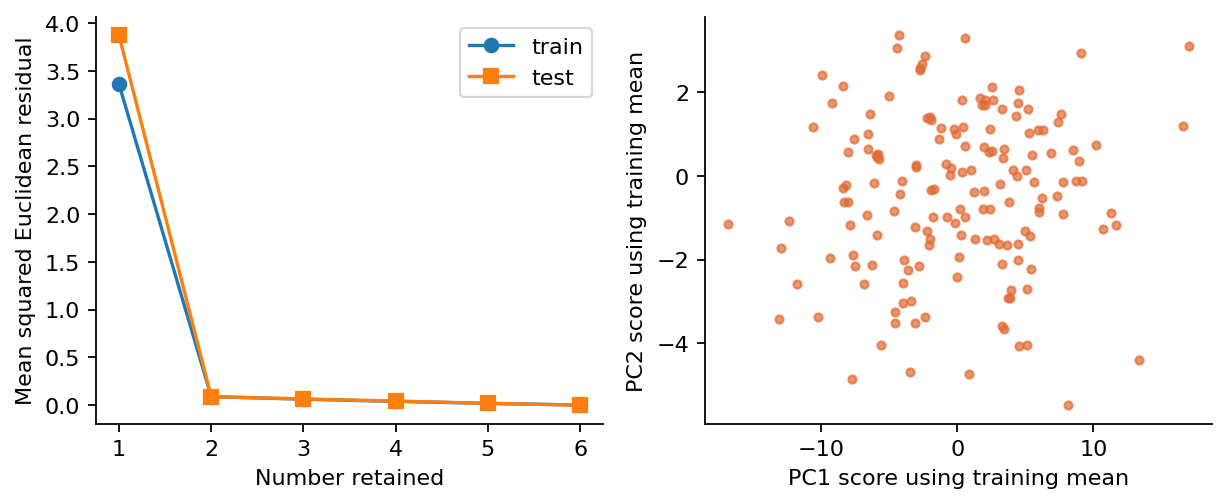

In [11]:
display(Image(filename="outputs/notebook-figures/04_reconstruction.png"))

### 单位与标准化

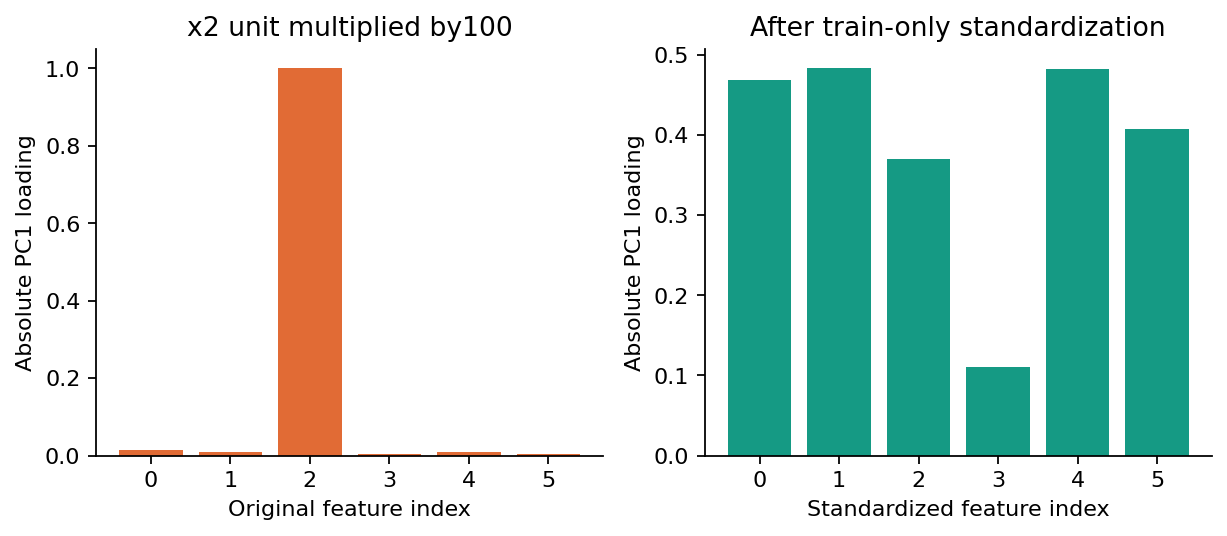

In [12]:
display(Image(filename="outputs/notebook-figures/05_scaling.png"))

### 预测信息反例

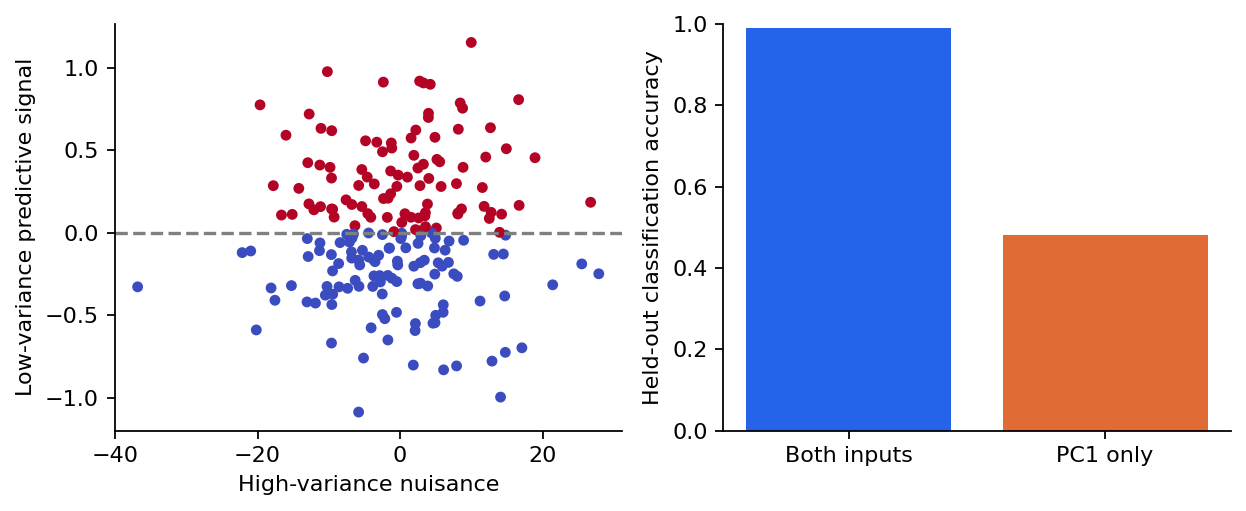

In [13]:
display(Image(filename="outputs/notebook-figures/06_signal_counterexample.png"))

### 训练坐标系

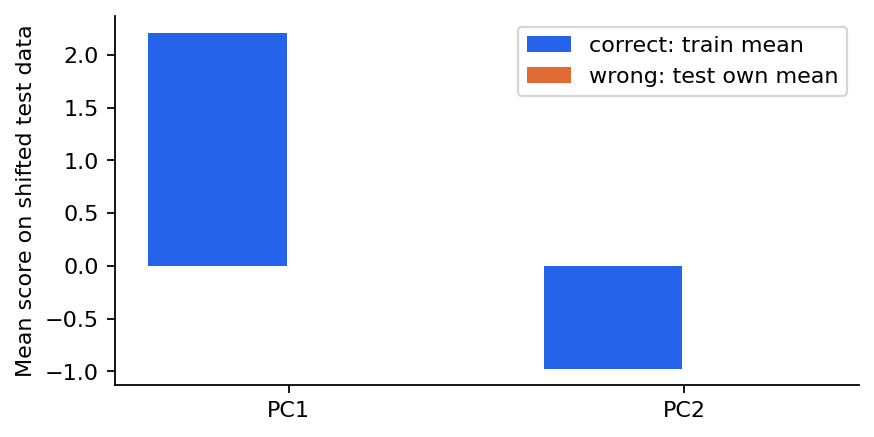

In [14]:
display(Image(filename="outputs/notebook-figures/07_centering_leakage.png"))

## 小结
训练集拟合均值与主轴，新样本只变换。SSE=(n-1)乘丢弃特征值之和；本讲图中误差再除以n而不是nd。PCA的几何最优性不替代下游任务验证。